# Self-Distillation Fine-Tuning vs. Standard Fine-Tuning
## Benchmark: SST-2 (GLUE) | Model: distilbert-base-uncased | Hardware: T4 GPU

### Research Motivation
This notebook implements and evaluates the **Self-Distilled Fine-Tuning** method proposed in:
> *Fine-Tuning Large Language Models: Mechanisms and Adaptation Strategies*

The core idea: during fine-tuning, distill the frozen **original pretrained model's** output distribution
into the adapting model via a KL-divergence loss. The total loss is:

$$\mathcal{L}_{total} = \mathcal{L}_{task} + \lambda \cdot \mathcal{L}_{KD}$$

where $\mathcal{L}_{KD} = T^2 \cdot \text{KL}(p_{teacher}/T \| p_{student}/T)$ (temperature-scaled KL).

### Experimental Design
| | Standard FT | Self-Distill FT (λ=0.3) | Self-Distill FT (λ=0.7) |
|---|---|---|---|
| Task loss | ✅ CE | ✅ CE | ✅ CE |
| KD loss | ❌ | ✅ (λ=0.3) | ✅ (λ=0.7) |
| Teacher | — | frozen pretrained | frozen pretrained |

**Primary metric**: Accuracy on SST-2 dev set (GLUE)  
**Secondary metrics**: Training loss curves, convergence speed, eval loss


In [1]:
# Install dependencies
# Pin numpy<2 — Colab ships NumPy 2.x which breaks datasets.set_format('torch')
!pip install -q 'numpy<2.0' transformers==4.44.0 datasets==2.20.0 evaluate==0.4.2 accelerate==0.33.0
# Force kernel to pick up the pinned numpy without a full restart
# NOTE: After running this cell, you must restart the Colab runtime (Runtime -> Restart runtime...)
# to ensure the downgraded NumPy version is correctly loaded by all libraries.
import importlib, numpy
print(f"NumPy version: {numpy.__version__}")

import os, random, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
import evaluate
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

NumPy version: 1.26.4
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Dataset: SST-2 (GLUE)
Stanford Sentiment Treebank — binary sentiment classification.  
Train: 67,349 | Dev: 872 | Test: 1,821 (labels hidden on GLUE)

In [2]:
# ── Load SST-2 from GLUE ──────────────────────────────────────────────────────
dataset = load_dataset('glue', 'sst2')
print(dataset)

# We use the official validation split for evaluation
# Train split = 67,349 | Validation = 872
print(f"\nTrain size : {len(dataset['train'])}")
print(f"Validation : {len(dataset['validation'])}")
print(f"Sample     : {dataset['train'][0]}")

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

Train size : 67349
Validation : 872
Sample     : {'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


## 3. Model & Tokenizer
Using `distilbert-base-uncased` (66M params) — fits comfortably on T4 with two copies (student + frozen teacher) in fp32.

In [3]:
MODEL_NAME = 'distilbert-base-uncased'
NUM_LABELS = 2
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch['sentence'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=['sentence', 'idx'])
tokenized = tokenized.rename_column('label', 'labels')

# Use with_format (returns a new dataset view) — avoids the numpy 2.x copy= issue
# that triggers when set_format calls np.array(..., copy=False) internally.
tokenized = tokenized.with_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenization complete.')
sample = tokenized['train'][0]
print(f"input_ids dtype : {sample['input_ids'].dtype}")
print(f"input_ids shape : {tuple(sample['input_ids'].shape)}")
print(f"labels          : {sample['labels']}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Tokenization complete.
input_ids dtype : torch.int64
input_ids shape : (128,)
labels          : 0


## 4. DataLoaders

In [4]:
BATCH_SIZE = 32   # fits T4 with two model copies

train_loader = DataLoader(
    tokenized['train'],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    tokenized['validation'],
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 2105
Val batches   : 14


## 5. Core Training Infrastructure

### 5.1 — Self-Distillation Loss
$$\mathcal{L}_{KD} = T^2 \cdot \text{KL}\left(\text{softmax}\left(\frac{z_t}{T}\right) \| \text{log\_softmax}\left(\frac{z_s}{T}\right)\right)$$

where $z_t$ are teacher logits (frozen pretrained model), $z_s$ are student logits, and $T$ is temperature.

In [5]:
def distillation_loss(student_logits, teacher_logits, temperature=4.0):
    """
    Symmetric KL-divergence between softened teacher and student distributions.
    Scaled by T^2 following Hinton et al. (2015) to maintain gradient magnitude.
    """
    T = temperature
    p_teacher = F.softmax(teacher_logits / T, dim=-1)      # soft labels
    log_p_student = F.log_softmax(student_logits / T, dim=-1)
    kd_loss = F.kl_div(log_p_student, p_teacher, reduction='batchmean') * (T ** 2)
    return kd_loss


class SelfDistillTrainer:
    """
    Trains a student model on task CE loss + KD loss from a frozen teacher
    (the original pretrained model). When lambda_kd=0, reduces to standard FT.
    """
    def __init__(
        self,
        model_name,
        num_labels,
        lambda_kd=0.0,
        temperature=4.0,
        lr=2e-5,
        epochs=3,
        warmup_ratio=0.1,
        weight_decay=0.01,
        device=DEVICE
    ):
        self.lambda_kd   = lambda_kd
        self.temperature = temperature
        self.epochs      = epochs
        self.device      = device
        self.run_name    = f"lambda={lambda_kd}"

        # ── Student model (to be fine-tuned) ─────────────────────────────────
        self.student = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels
        ).to(device)

        # ── Teacher model (frozen pretrained, only used if lambda_kd > 0) ────
        if lambda_kd > 0:
            self.teacher = AutoModelForSequenceClassification.from_pretrained(
                model_name, num_labels=num_labels
            ).to(device)
            for p in self.teacher.parameters():
                p.requires_grad = False
            self.teacher.eval()
            print(f"[{self.run_name}] Teacher loaded and frozen.")
        else:
            self.teacher = None
            print(f"[{self.run_name}] Standard FT (no distillation teacher).")

        # ── Optimizer & scheduler ─────────────────────────────────────────────
        self.optimizer = torch.optim.AdamW(
            self.student.parameters(), lr=lr, weight_decay=weight_decay
        )
        total_steps = len(train_loader) * epochs
        warmup_steps = int(total_steps * warmup_ratio)
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        self.metric = evaluate.load('glue', 'sst2')
        self.history = {'train_loss': [], 'task_loss': [], 'kd_loss': [], 'val_acc': [], 'val_loss': []}

    def train_epoch(self):
        self.student.train()
        total_loss = total_task = total_kd = 0
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels         = batch['labels'].to(self.device)

            # Student forward
            out = self.student(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            task_loss = out.loss
            student_logits = out.logits

            # KD loss from frozen teacher
            if self.teacher is not None and self.lambda_kd > 0:
                with torch.no_grad():
                    teacher_out = self.teacher(input_ids=input_ids, attention_mask=attention_mask)
                kd = distillation_loss(student_logits, teacher_out.logits, self.temperature)
                loss = (1 - self.lambda_kd) * task_loss + self.lambda_kd * kd
                total_kd += kd.item()
            else:
                loss = task_loss

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.student.parameters(), 1.0)
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()
            total_task += task_loss.item()

        n = len(train_loader)
        return total_loss / n, total_task / n, total_kd / n

    @torch.no_grad()
    def evaluate(self):
        self.student.eval()
        total_loss = 0
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels         = batch['labels'].to(self.device)
            out = self.student(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            preds = out.logits.argmax(dim=-1)
            self.metric.add_batch(predictions=preds, references=labels)
            total_loss += out.loss.item()
        result = self.metric.compute()
        return result['accuracy'], total_loss / len(val_loader)

    def run(self):
        print(f"\n{'='*60}")
        print(f"  Experiment: Self-Distillation FT | λ = {self.lambda_kd}")
        print(f"  Model: {MODEL_NAME} | Dataset: SST-2 (GLUE)")
        print(f"  Epochs: {self.epochs} | Batch: {BATCH_SIZE} | LR: 2e-5")
        print(f"  Temperature: {self.temperature} | Warmup: 10%")
        print(f"{'='*60}")

        t0 = time.time()
        for epoch in range(1, self.epochs + 1):
            t_ep = time.time()
            tr_loss, task_loss, kd_loss = self.train_epoch()
            val_acc, val_loss = self.evaluate()
            elapsed = time.time() - t_ep

            self.history['train_loss'].append(tr_loss)
            self.history['task_loss'].append(task_loss)
            self.history['kd_loss'].append(kd_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_loss'].append(val_loss)

            print(
                f"Epoch {epoch}/{self.epochs} | "
                f"Train Loss: {tr_loss:.4f} (task={task_loss:.4f}, kd={kd_loss:.4f}) | "
                f"Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f} | "
                f"Time: {elapsed:.0f}s"
            )

        total_time = time.time() - t0
        best_acc = max(self.history['val_acc'])
        print(f"\nBest Val Accuracy: {best_acc:.4f} | Total Time: {total_time/60:.1f} min")
        return self.history, best_acc

## 6. Run Experiments

Three runs on the same hardware, same seed, same data:
- **Baseline**: Standard fine-tuning (λ=0)
- **SdFT-0.3**: Self-Distillation with λ=0.3 (mild regularization)
- **SdFT-0.7**: Self-Distillation with λ=0.7 (strong anchoring)

> Expected T4 runtime: ~15–20 min per run (3 epochs × 67K samples)

In [7]:
EPOCHS = 3
TEMPERATURE = 4.0
results = {}

# ── Experiment 1: Standard Fine-Tuning (Baseline) ────────────────────────────
set_seed(SEED)
trainer_std = SelfDistillTrainer(
    MODEL_NAME, NUM_LABELS,
    lambda_kd=0.0, temperature=TEMPERATURE, epochs=EPOCHS
)
hist_std, best_std = trainer_std.run()
results['Standard FT (λ=0)'] = {'history': hist_std, 'best_acc': best_std}
del trainer_std
torch.cuda.empty_cache()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[lambda=0.0] Standard FT (no distillation teacher).

  Experiment: Self-Distillation FT | λ = 0.0
  Model: distilbert-base-uncased | Dataset: SST-2 (GLUE)
  Epochs: 3 | Batch: 32 | LR: 2e-5
  Temperature: 4.0 | Warmup: 10%
Epoch 1/3 | Train Loss: 0.2675 (task=0.2675, kd=0.0000) | Val Acc: 0.9060 | Val Loss: 0.2543 | Time: 766s
Epoch 2/3 | Train Loss: 0.1248 (task=0.1248, kd=0.0000) | Val Acc: 0.9048 | Val Loss: 0.3026 | Time: 766s
Epoch 3/3 | Train Loss: 0.0838 (task=0.0838, kd=0.0000) | Val Acc: 0.9048 | Val Loss: 0.3516 | Time: 764s

Best Val Accuracy: 0.9060 | Total Time: 38.3 min


In [8]:
# ── Experiment 2: Self-Distillation FT (λ=0.3) ───────────────────────────────
set_seed(SEED)
trainer_03 = SelfDistillTrainer(
    MODEL_NAME, NUM_LABELS,
    lambda_kd=0.3, temperature=TEMPERATURE, epochs=EPOCHS
)
hist_03, best_03 = trainer_03.run()
results['SdFT (λ=0.3)'] = {'history': hist_03, 'best_acc': best_03}
del trainer_03
torch.cuda.empty_cache()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[lambda=0.3] Teacher loaded and frozen.

  Experiment: Self-Distillation FT | λ = 0.3
  Model: distilbert-base-uncased | Dataset: SST-2 (GLUE)
  Epochs: 3 | Batch: 32 | LR: 2e-5
  Temperature: 4.0 | Warmup: 10%
Epoch 1/3 | Train Loss: 0.3123 (task=0.3560, kd=0.2103) | Val Acc: 0.9083 | Val Loss: 0.3113 | Time: 1041s
Epoch 2/3 | Train Loss: 0.2618 (task=0.2580, kd=0.2708) | Val Acc: 0.9071 | Val Loss: 0.3151 | Time: 1036s
Epoch 3/3 | Train Loss: 0.2485 (task=0.2322, kd=0.2865) | Val Acc: 0.9060 | Val Loss: 0.3188 | Time: 1037s

Best Val Accuracy: 0.9083 | Total Time: 51.9 min


In [9]:
# ── Experiment 3: Self-Distillation FT (λ=0.7) ───────────────────────────────
set_seed(SEED)
trainer_07 = SelfDistillTrainer(
    MODEL_NAME, NUM_LABELS,
    lambda_kd=0.7, temperature=TEMPERATURE, epochs=EPOCHS
)
hist_07, best_07 = trainer_07.run()
results['SdFT (λ=0.7)'] = {'history': hist_07, 'best_acc': best_07}
del trainer_07
torch.cuda.empty_cache()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[lambda=0.7] Teacher loaded and frozen.

  Experiment: Self-Distillation FT | λ = 0.7
  Model: distilbert-base-uncased | Dataset: SST-2 (GLUE)
  Epochs: 3 | Batch: 32 | LR: 2e-5
  Temperature: 4.0 | Warmup: 10%
Epoch 1/3 | Train Loss: 0.1778 (task=0.5198, kd=0.0313) | Val Acc: 0.9117 | Val Loss: 0.4960 | Time: 1039s
Epoch 2/3 | Train Loss: 0.1691 (task=0.4712, kd=0.0397) | Val Acc: 0.9117 | Val Loss: 0.4983 | Time: 1037s
Epoch 3/3 | Train Loss: 0.1670 (task=0.4590, kd=0.0418) | Val Acc: 0.9071 | Val Loss: 0.4951 | Time: 1037s

Best Val Accuracy: 0.9117 | Total Time: 51.9 min


In [10]:
# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Method':<25} {'Best Val Acc':>12} {'Δ vs Baseline':>15}")
print("-"*65)
baseline_acc = results['Standard FT (λ=0)']['best_acc']
for method, r in results.items():
    delta = r['best_acc'] - baseline_acc
    delta_str = f"+{delta:.4f}" if delta >= 0 else f"{delta:.4f}"
    print(f"{method:<25} {r['best_acc']:>12.4f} {delta_str:>15}")
print("="*65)


Method                    Best Val Acc   Δ vs Baseline
-----------------------------------------------------------------
Standard FT (λ=0)               0.9060         +0.0000
SdFT (λ=0.3)                    0.9083         +0.0023
SdFT (λ=0.7)                    0.9117         +0.0057


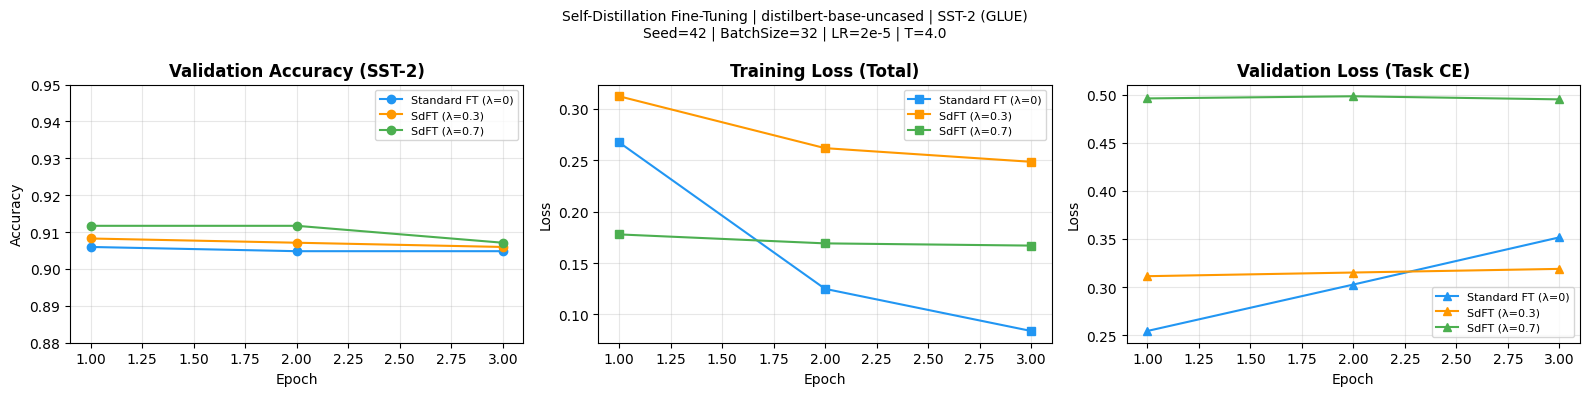

Saved: learning_curves.png


In [11]:
# ── Learning Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_x = range(1, EPOCHS + 1)
colors = {'Standard FT (λ=0)': '#2196F3', 'SdFT (λ=0.3)': '#FF9800', 'SdFT (λ=0.7)': '#4CAF50'}

# Val Accuracy
ax = axes[0]
for method, r in results.items():
    ax.plot(epochs_x, r['history']['val_acc'], marker='o', label=method, color=colors[method])
ax.set_title('Validation Accuracy (SST-2)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_ylim([0.88, 0.95])

# Train Loss
ax = axes[1]
for method, r in results.items():
    ax.plot(epochs_x, r['history']['train_loss'], marker='s', label=method, color=colors[method])
ax.set_title('Training Loss (Total)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Val Loss
ax = axes[2]
for method, r in results.items():
    ax.plot(epochs_x, r['history']['val_loss'], marker='^', label=method, color=colors[method])
ax.set_title('Validation Loss (Task CE)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Self-Distillation Fine-Tuning | distilbert-base-uncased | SST-2 (GLUE)\n'
    f'Seed={SEED} | BatchSize={BATCH_SIZE} | LR=2e-5 | T={TEMPERATURE}',
    fontsize=10
)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

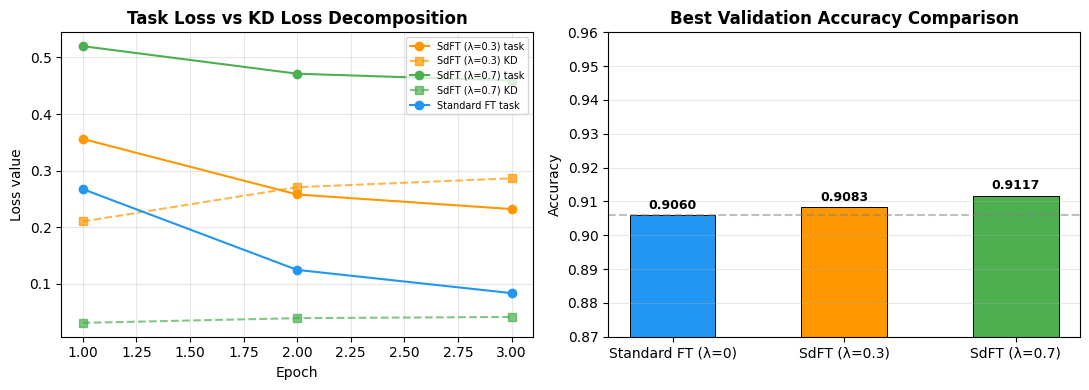

Saved: kd_analysis.png


In [12]:
# ── KD Loss Decomposition (SdFT runs only) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for method in ['SdFT (λ=0.3)', 'SdFT (λ=0.7)']:
    r = results[method]
    ax.plot(epochs_x, r['history']['task_loss'], marker='o', linestyle='-', label=f"{method} task", color=colors[method])
    ax.plot(epochs_x, r['history']['kd_loss'],   marker='s', linestyle='--', label=f"{method} KD",   color=colors[method], alpha=0.7)
# also plot std baseline task
ax.plot(epochs_x, results['Standard FT (λ=0)']['history']['task_loss'],
        marker='o', linestyle='-', label='Standard FT task', color=colors['Standard FT (λ=0)'])
ax.set_title('Task Loss vs KD Loss Decomposition', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss value')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Bar chart: best accuracy comparison
ax = axes[1]
methods = list(results.keys())
accs    = [results[m]['best_acc'] for m in methods]
bars = ax.bar(methods, accs, color=[colors[m] for m in methods], width=0.5, edgecolor='black', linewidth=0.7)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim([0.87, 0.96])
ax.set_title('Best Validation Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy'); ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=accs[0], linestyle='--', color='gray', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.savefig('kd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kd_analysis.png")

In [13]:
import json, datetime

report = {
    'experiment': 'Self-Distillation Fine-Tuning vs Standard FT',
    'paper': 'Fine-Tuning Large Language Models: Mechanisms and Adaptation Strategies',
    'dataset': 'SST-2 (GLUE)',
    'model': MODEL_NAME,
    'hyperparameters': {
        'seed': SEED,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': 2e-5,
        'weight_decay': 0.01,
        'warmup_ratio': 0.1,
        'max_seq_len': MAX_LEN,
        'kd_temperature': TEMPERATURE
    },
    'timestamp': datetime.datetime.now().isoformat(),
    'results': {
        method: {
            'best_val_accuracy': r['best_acc'],
            'delta_vs_baseline': r['best_acc'] - baseline_acc,
            'val_acc_per_epoch': r['history']['val_acc'],
            'train_loss_per_epoch': r['history']['train_loss'],
            'val_loss_per_epoch': r['history']['val_loss'],
        }
        for method, r in results.items()
    }
}

with open('results.json', 'w') as f:
    json.dump(report, f, indent=2)

print("Results saved to results.json")
print(json.dumps(report['results'], indent=2))

Results saved to results.json
{
  "Standard FT (\u03bb=0)": {
    "best_val_accuracy": 0.9059633027522935,
    "delta_vs_baseline": 0.0,
    "val_acc_per_epoch": [
      0.9059633027522935,
      0.9048165137614679,
      0.9048165137614679
    ],
    "train_loss_per_epoch": [
      0.26747957865515115,
      0.12484392706247273,
      0.08383003049452663
    ],
    "val_loss_per_epoch": [
      0.25428966326372965,
      0.30256069877317976,
      0.351607008171933
    ]
  },
  "SdFT (\u03bb=0.3)": {
    "best_val_accuracy": 0.908256880733945,
    "delta_vs_baseline": 0.002293577981651418,
    "val_acc_per_epoch": [
      0.908256880733945,
      0.9071100917431193,
      0.9059633027522935
    ],
    "train_loss_per_epoch": [
      0.3123231685996905,
      0.2618145419766954,
      0.2485280742271496
    ],
    "val_loss_per_epoch": [
      0.3112510229860033,
      0.3150622397661209,
      0.3188487482922418
    ]
  },
  "SdFT (\u03bb=0.7)": {
    "best_val_accuracy": 0.9116972477